## 4.5 애니온을 이용한 위상학적 양자 컴퓨팅 (Topological Quantum Computing with Anyons)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 애니온의 땋기를 나타내는 함수 정의
def braid_anyons(circuit, qubit1, qubit2):
    circuit.cx(qubit1, qubit2)
    circuit.cz(qubit2, qubit1)
    circuit.cx(qubit1, qubit2)

In [3]:
# 큐비트 3개로 양자 회로 초기화
qc = QuantumCircuit(3, 3)  # 측정용 큐비트 3개 + 고전 비트 3개

In [4]:
# 큐비트 0, 1을 애니온으로, 큐비트 2를 보조로 가정
qc.h(0)
qc.h(1)

In [5]:
# 일련의 땋기 수행
braid_anyons(qc, 0, 1)
braid_anyons(qc, 1, 2)
braid_anyons(qc, 0, 2)

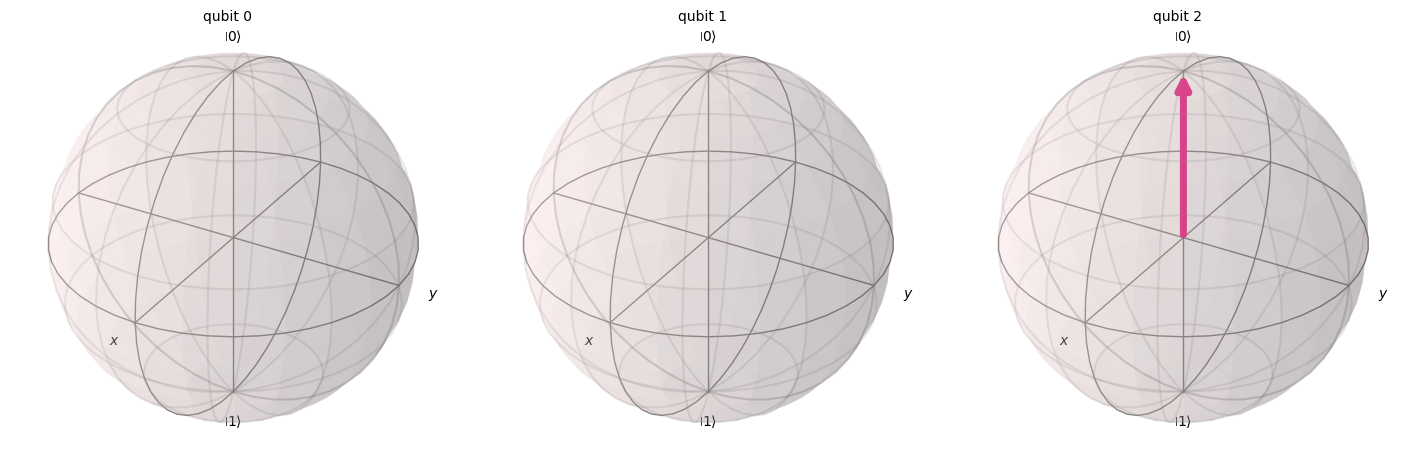

In [6]:
# 블로흐 구 시각화를 위해 최종 상태벡터 얻기
final_state = Statevector.from_instruction(qc)
plot_bloch_multivector(final_state)
plt.show()

In [7]:
# 최종 측정 적용
qc.measure([0, 1, 2], [0, 1, 2])

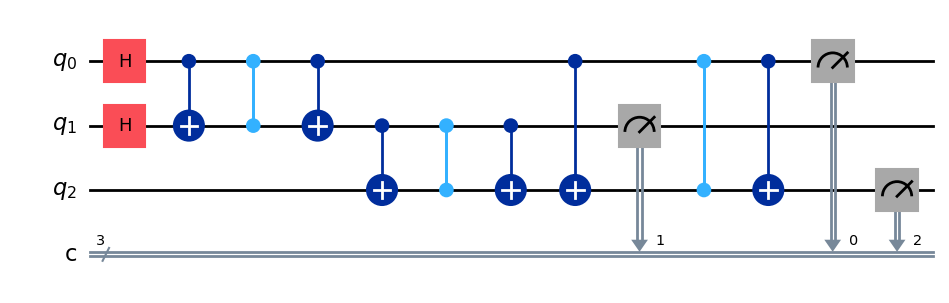

In [8]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [9]:
# AerSimulator로 회로 시뮬레이션
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

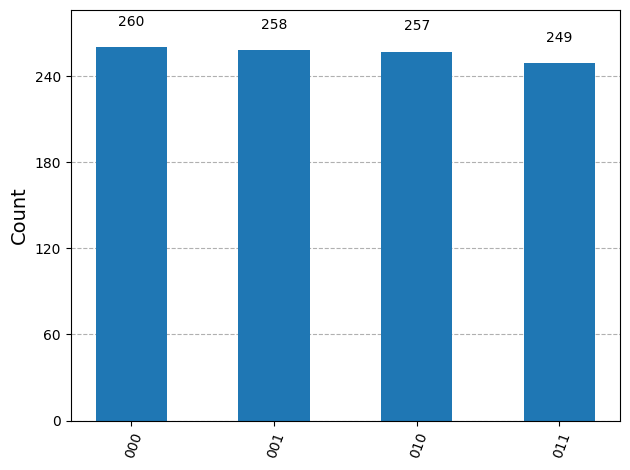

In [10]:
# 결과를 얻어 그리기
counts = result.get_counts()
plot_histogram(counts)
plt.show()